In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

In [2]:
os.makedirs("charts", exist_ok=True)

In [4]:
restaurants = pd.read_csv("/Users/aakashreddy/Desktop/fast-food-restaurant-analysis/data/raw/fast_food_restaurants.csv")

restaurants.head()

,address,city,country,keys,latitude,longitude,name,postalCode,province,websites
0,324 Main St,Massena,US,us/ny/massena/324mainst/-1161002137,44.92130,-74.89021,McDonald's,13662,NY,"http://mcdonalds.com,http://www.mcdonalds.com/..."
1,530 Clinton Ave,Washington Court House,US,us/oh/washingtoncourthouse/530clintonave/-7914...,39.53255,-83.44526,Wendy's,43160,OH,http://www.wendys.com
2,408 Market Square Dr,Maysville,US,us/ky/maysville/408marketsquaredr/1051460804,38.62736,-83.79141,Frisch's Big Boy,41056,KY,"http://www.frischs.com,https://www.frischs.com..."
3,6098 State Highway 37,Massena,US,us/ny/massena/6098statehighway37/-1161002137,44.95008,-74.84553,McDonald's,13662,NY,"http://mcdonalds.com,http://www.mcdonalds.com/..."
4,139 Columbus Rd,Athens,US,us/oh/athens/139columbusrd/990890980,39.35155,-82.09728,OMG! Rotisserie,45701,OH,"http://www.omgrotisserie.com,http://omgrotisse..."


In [5]:
restaurants["name"].value_counts().head(20)

name
McDonald's                               1886
Burger King                              1154
Taco Bell                                 873
Wendy's                                   731
Arby's                                    518
KFC                                       421
Domino's Pizza                            345
Subway                                    322
SONIC Drive In                            226
Hardee's                                  192
Jack in the Box                           187
Jimmy John's                              157
Pizza Hut                                 128
Sonic Drive-In                            126
Bojangles' Famous Chicken 'n Biscuits     126
McDonalds                                 111
Chick-fil-A                               100
Five Guys                                  96
Dairy Queen                                92
Whataburger                                88
Name: count, dtype: int64

In [6]:
restaurants["name"] = restaurants["name"].replace(
    {
        "McDonalds": "McDonald's"
    }
)

In [8]:
restaurants["name"].value_counts().head(20)

name
McDonald's                               1997
Burger King                              1154
Taco Bell                                 873
Wendy's                                   731
Arby's                                    518
KFC                                       421
Domino's Pizza                            345
Subway                                    322
SONIC Drive In                            226
Hardee's                                  192
Jack in the Box                           187
Jimmy John's                              157
Pizza Hut                                 128
Sonic Drive-In                            126
Bojangles' Famous Chicken 'n Biscuits     126
Chick-fil-A                               100
Five Guys                                  96
Dairy Queen                                92
Whataburger                                88
Mcdonald's                                 85
Name: count, dtype: int64

In [10]:
restaurants["name"] = restaurants["name"].replace(
    {
        "Mcdonald's": "McDonald's"
    }
)

In [12]:
restaurants["name"].value_counts().head(20)

name
McDonald's                               2082
Burger King                              1154
Taco Bell                                 873
Wendy's                                   731
Arby's                                    518
KFC                                       421
Domino's Pizza                            345
Subway                                    322
SONIC Drive In                            226
Hardee's                                  192
Jack in the Box                           187
Jimmy John's                              157
Pizza Hut                                 128
Sonic Drive-In                            126
Bojangles' Famous Chicken 'n Biscuits     126
Chick-fil-A                               100
Five Guys                                  96
Dairy Queen                                92
Whataburger                                88
SUBWAY                                     82
Name: count, dtype: int64

In [13]:
restaurant_counts = (
    restaurants.groupby("name")
    .size()
    .reset_index(name="location_count")
)

restaurant_counts.head()

,name,location_count
0,31st Avenue Gyro,1
1,7-11,1
2,7-Eleven,1
3,A & W Family Restaurant,1
4,A&W,3


In [16]:
restaurant_counts = restaurant_counts.sort_values(
    "location_count",
    ascending=False
)

restaurant_counts.head(10)

,name,location_count
312,McDonald's,2082
61,Burger King,1154
476,Taco Bell,873
523,Wendy's,731
17,Arby's,518
258,KFC,421
154,Domino's Pizza,345
467,Subway,322
420,SONIC Drive In,226
214,Hardee's,192


In [17]:
top10 = restaurant_counts.head(10)

top10

,name,location_count
312,McDonald's,2082
61,Burger King,1154
476,Taco Bell,873
523,Wendy's,731
17,Arby's,518
258,KFC,421
154,Domino's Pizza,345
467,Subway,322
420,SONIC Drive In,226
214,Hardee's,192


In [20]:
top10.to_csv(
    "/Users/aakashreddy/Desktop/fast-food-restaurant-analysis/charts/question4_results.csv",
    index=False
)

print("Results saved successfully")

Results saved successfully


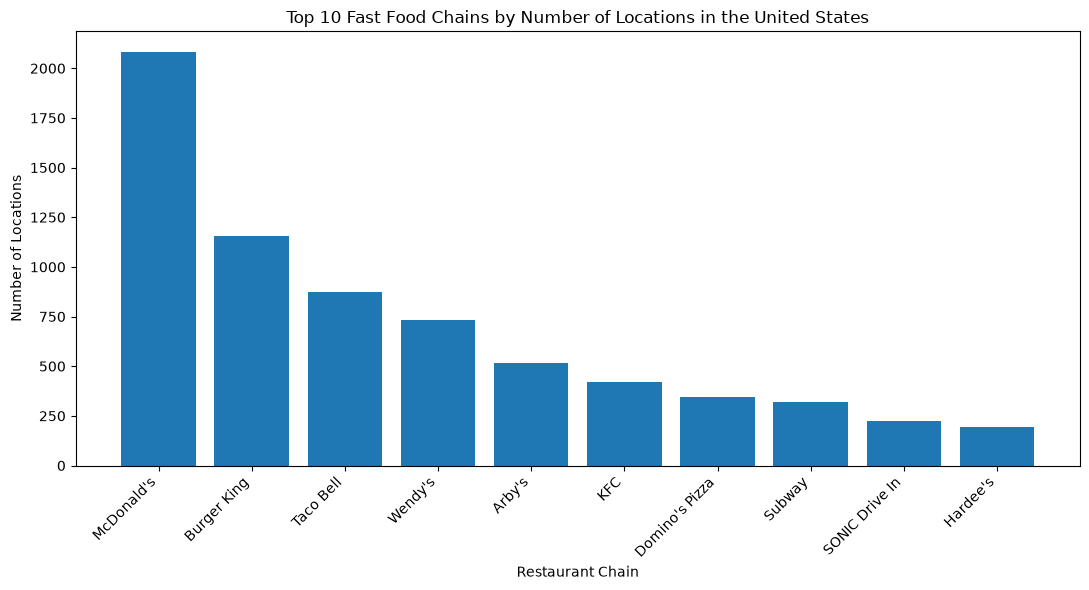

In [21]:
plt.figure(figsize=(11,6))

plt.bar(
    top10["name"],
    top10["location_count"]
)

plt.title(
    "Top 10 Fast Food Chains by Number of Locations in the United States"
)

plt.xlabel("Restaurant Chain")
plt.ylabel("Number of Locations")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()

plt.savefig(
    "/Users/aakashreddy/Desktop/fast-food-restaurant-analysis/charts/question4_top10.png",
    dpi=300
)

plt.show()